In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import netCDF4 as nc
from datetime import datetime
import statsmodels.api as sm
from shapely.geometry import LineString, Point
import matplotlib.pyplot as plt

import sys
sys.path.insert(0,"/home/scottleeyoung/codes/statistics")
import fortsa
import romspy

In [2]:
def get_indices_1d_coords(lon, lat, start, end):
    """
    Get indices of grid cells between two points along a straight line,
    ensuring only one index per column (longitude).

    Parameters:
        lon (1D array): Longitudes of the grid.
        lat (1D array): Latitudes of the grid.
        start (tuple): (lon, lat) of the starting point.
        end (tuple): (lon, lat) of the ending point.

    Returns:
        List of (i, j) index tuples where i = lat index, j = lon index.
    """

    # Make 2D grid
    lon_grid, lat_grid = np.meshgrid(lon, lat)
    
    # Create line between start and end
    line = LineString([start, end])

    selected_indices = {}

    # Loop over all grid cells
    for j, lon_val in enumerate(lon):
        for i, lat_val in enumerate(lat):
            point = Point(lon_val, lat_val)
            dist = line.distance(point)

            # Use a reasonable threshold to select points near the line
            threshold = max(np.diff(lon).mean(), np.diff(lat).mean()) * 0.75

            if dist < threshold:
                # Only keep the closest i for each j (1 index per column)
                if j not in selected_indices or dist < selected_indices[j][0]:
                    selected_indices[j] = (dist, (i, j))

    # Extract only the (i, j) parts, sorted by column (j)
    result = [val[1] for _, val in sorted(selected_indices.items())]
    return np.array(result)

In [3]:
estuary_res_file = "/orange/olabarrieta/scottleeyoung/slew/observations/SLE_obs.nc"
river_file = "/orange/olabarrieta/scottleeyoung/slew/Jan-01-2010_to_Jan-01-2021/forcings/SLEW_rivers-final_Jan-01-2010_to_Dec-31-2020.nc"
wind_speed_file = "/orange/olabarrieta/scottleeyoung/slew/observations/wind/SVWX_WSPE_Jan-01-2010_to_Jan-01-2021.csv"
wind_dir_file = "/orange/olabarrieta/scottleeyoung/slew/observations/wind/SVWX_WDIR_Jan-01-2010_to_Jan-01-2021.csv"
gs_tracer_file = "/orange/olabarrieta/scottleeyoung/slew/Jan-01-2010_to_Jan-01-2021/forcings/CopernicusMarine_data_Jan-01-2010_to_Jan-01-2021.nc"
air_temp_file = "/orange/olabarrieta/scottleeyoung/slew/observations/SVWX_airt_Jan-01-2010_to_Jan-01-2021.csv"
radt_file = "data/SVWX_RADT_Jan-01-2010_to_Jan-01-2021.csv"
cutoff_period = 21
kb_alpha = 4.8
dt_wind = 15/1440
dt_est = 15/1440
dt_tran = 1
dt_flow = 1
dt_air = 1
dt_radt = 1

In [4]:
# #====================================================
# River Discharge
# read data
ds = xr.open_dataset(river_file)
flow_time = ds['river_time'].values#[2557:2557+365]
flow = np.abs(ds['river_transport'].values)#[2557:2557+365,:])
ds.close()
total_flow = np.sum(flow,axis=1)
total_flow = romspy.interpolate_nans(total_flow)
flow_time = romspy.extract_datetime(flow_time)
flow_time = romspy.str_datetime_2_ord(flow_time, "1858-11-17 00:00:00", '%Y-%m-%d %H:%M:%S')#[2557:2557+365]
flow = np.sum(flow,axis=1)

#====================================================
# Florida Current Transport
FC_tran = []
year = []
month = []
day = []
for i in range(11):
    FC_tran_file = f"/orange/olabarrieta/scottleeyoung/FC_transport_data/FC_cable_transport_{2010+i}_v2.dat"
    year.append(np.loadtxt(FC_tran_file, skiprows=42, usecols=0))
    month.append(np.loadtxt(FC_tran_file, skiprows=42, usecols=1))
    day.append(np.loadtxt(FC_tran_file, skiprows=42, usecols=2))
    FC_tran.append(np.loadtxt(FC_tran_file, skiprows=42, usecols=3))

FC_tran = np.concatenate(FC_tran)
year = np.concatenate(year)
month = np.concatenate(month)
day = np.concatenate(day)
FC_time = np.empty(year.size, dtype="<U19")
for i in range(year.size):
    FC_time[i] = f"{int(year[i])}-{int(month[i]):02d}-{int(day[i]):02d} 00:00:00"
FC_time = romspy.str_datetime_2_ord(FC_time, "1858-11-17 00:00:00", '%Y-%m-%d %H:%M:%S')

#====================================================
# Gulf Stream Tracers
# read data
ds = xr.open_dataset(gs_tracer_file, decode_timedelta=False)
temp_ds = ds['temp'].values
salt_ds = ds['salt'].values
lon_ds = ds['lon'].values
lat_ds = ds['lat'].values
depth = ds['depth'].values
gs_time = ds['time'].values[:-1]#/86400e9
ds.close()

# extract cross-section
start = (-78.819322,26.479712)
end = (-80.022494,26.684782)
indx = get_indices_1d_coords(lon_ds, lat_ds, start, end)

N = salt_ds.shape[0]
M = indx.shape[0]
temp = np.empty([N,depth.size,M])
salt = np.empty([N,depth.size,M])
lon = np.empty([M])
lat = np.empty([M])
for i in range(M):
    lon[i] = lon_ds[indx[i,1]]
    lat[i] = lat_ds[indx[i,0]]
    temp[:,:,i] = temp_ds[:,:,indx[i,0],indx[i,1]]
    salt[:,:,i] = salt_ds[:,:,indx[i,0],indx[i,1]]

# extract depth
temp[temp > 100] = np.nan
salt[salt > 100] = np.nan
B = romspy.haversine(lat[0], lon[0], lat[-1], lon[-1]) * 1000
h = np.empty(M)
indx = np.empty(M, dtype=int)
for i in range(M):
    indx[i] = np.where(np.isnan(np.nanmean(temp,axis=0)[:,i]))[0].min()
    h[i] = depth[indx[i]]
    
# depth average
dA = h.mean() * B / (indx.mean() * M)
A = h.mean() * B
gs_temp = np.nansum(temp,axis=(1,2)) * dA / A
gs_salt = np.nansum(salt,axis=(1,2)) * dA / A

#====================================================
# Winds
# read data
svwx_wind_file = wind_speed_file
df = pd.read_csv(svwx_wind_file)
svwx = df.iloc[:,1].to_numpy()
df['Date-Time'] = pd.to_datetime(df['Date-Time'], format='%m-%d-%Y %H:%M', errors='coerce')
svwx_spe_time = df.iloc[:,0].to_numpy()
svwx_spe_time = romspy.extract_datetime(svwx_spe_time)
for i in range(svwx_spe_time.size):
    if svwx_spe_time[i] == 'NaT' or svwx_spe_time[i] == 'NaT ':
        svwx_spe_time[i] = np.nan
    else:
        svwx_spe_time[i] = romspy.str_datetime_2_ord(np.array([svwx_spe_time[i]]), "1858-11-17 00:00:00", '%Y-%m-%d %H:%M:%S')[0]
svwx_spe_time = np.array(svwx_spe_time, dtype=float)
svwx = romspy.interpolate_nans(svwx)

svwx_wind_dir_file = wind_dir_file
df = pd.read_csv(svwx_wind_dir_file)
svwx_dirr = df.iloc[:,1].to_numpy()[:-1]
df['Date-Time'] = pd.to_datetime(df['Date-Time'], format='%m-%d-%Y %H:%M', errors='coerce')
svwx_dir_time = df.iloc[:,0].to_numpy()
svwx_dir_time = romspy.extract_datetime(svwx_dir_time)
for i in range(svwx_dir_time.size):
    if svwx_dir_time[i] == 'NaT' or svwx_dir_time[i] == 'NaT ':
        svwx_dir_time[i] = np.nan
    else:
        svwx_dir_time[i] = romspy.str_datetime_2_ord(np.array([svwx_dir_time[i]]), "1858-11-17 00:00:00", '%Y-%m-%d %H:%M:%S')[0]
svwx_dir_time = np.array(svwx_dir_time, dtype=float)

svwx_time = np.empty(int(4018/dt_wind))
svwx_time[0] = svwx_spe_time[0]
for i in range(1, int(4018/dt_wind)):
    svwx_time[i] = svwx_time[i-1] + dt_wind
svwx_dirr = romspy.interpolate_nans(svwx_dirr)

svwx_spe = romspy.interpolate_to_time(svwx_time, svwx_spe_time, svwx)
svwx_dir = romspy.interpolate_to_time(svwx_time, svwx_dir_time, svwx_dirr)
svwx_u = -svwx_spe * np.sin(np.radians(svwx_dir))
svwx_v = -svwx_spe * np.cos(np.radians(svwx_dir))

#====================================================
# Air Temperature
# read data
df = pd.read_csv(air_temp_file, skiprows=33, na_values=' ')
airt = df.iloc[:,5].to_numpy()[:-1]
airt_time = df.iloc[:,4].to_numpy()[:-1]
airt_time = romspy.str_datetime_2_ord(airt_time, "1858-11-17", "%Y-%m-%d")
airt = romspy.interpolate_nans(airt)

/scratch/local/29935642/ipykernel_1058576/1661006566.py:72: RuntimeWarning: Mean of empty slice
  indx[i] = np.where(np.isnan(np.nanmean(temp,axis=0)[:,i]))[0].min()


In [5]:
f_flow, psd_flow, _, sig_flow, _ = romspy.power_spectrum(flow, dt=1, method="welch", nperseg=365 * 3, detrend="constant", 
                                                         window="hann", alpha=0.90, ar1=None, nan_policy="omit")
f_tran, psd_tran, _, sig_tran, _ = romspy.power_spectrum(FC_tran, dt=1, method="welch", nperseg=365 * 3, detrend="constant", 
                                                         window="hann", alpha=0.90, ar1=None, nan_policy="omit")
f_gs_temp, psd_gs_temp, _, sig_gs_temp, _ = romspy.power_spectrum(gs_temp, dt=1, method="welch", nperseg=365 * 3, detrend="constant", 
                                                         window="hann", alpha=0.9, ar1=None, nan_policy="omit")
f_gs_salt, psd_gs_salt, _, sig_gs_salt, _ = romspy.power_spectrum(gs_salt, dt=1, method="welch", nperseg=365 * 3, detrend="constant", 
                                                         window="hann", alpha=0.9, ar1=None, nan_policy="omit")
f_windu, psd_windu, _, sig_windu, _ = romspy.power_spectrum(svwx_u, dt=15/1440, method="welch", nperseg=70128*1.5, detrend="constant", 
                                                         window="hann", alpha=0.9, ar1=None, nan_policy="omit")
f_windv, psd_windv, _, sig_windv, _ = romspy.power_spectrum(svwx_v, dt=15/1440, method="welch", nperseg=70128*1.5, detrend="constant", 
                                                         window="hann", alpha=0.9, ar1=None, nan_policy="omit")
f_airt, psd_airt, _, sig_airt, _ = romspy.power_spectrum(airt, dt=1, method="welch", nperseg=365*3, detrend="constant", 
                                                         window="hann", alpha=0.9, ar1=None, nan_policy="omit")

In [9]:
#====================================================
# Spectral Analysis of the Gulf Stream
ds = nc.Dataset("data/driver_fourier_sig90.nc", mode='w', format='NETCDF4')
ds.createDimension("freq_daily", f_tran.size)
ds.createDimension("freq_15min", f_windu.size)

v_f_flow = ds.createVariable("f_flow", "f8", ("freq_daily",))
v_psd_flow = ds.createVariable("psd_flow", "f8", ("freq_daily",))
v_sig_flow = ds.createVariable("sig_flow", "f8", ("freq_daily",))
v_f_tran = ds.createVariable("f_tran", "f8", ("freq_daily",))
v_psd_tran = ds.createVariable("psd_tran", "f8", ("freq_daily",))
v_sig_tran = ds.createVariable("sig_tran", "f8", ("freq_daily",))
v_f_gstemp = ds.createVariable("f_gstemp", "f8", ("freq_daily",))
v_psd_gstemp = ds.createVariable("psd_gstemp", "f8", ("freq_daily",))
v_sig_gstemp = ds.createVariable("sig_gstemp", "f8", ("freq_daily",))
v_f_gssalt = ds.createVariable("f_gssalt", "f8", ("freq_daily",))
v_psd_gssalt = ds.createVariable("psd_gssalt", "f8", ("freq_daily",))
v_sig_gssalt = ds.createVariable("sig_gssalt", "f8", ("freq_daily",))
v_f_airt = ds.createVariable("f_airt", "f8", ("freq_daily",))
v_psd_airt = ds.createVariable("psd_airt", "f8", ("freq_daily",))
v_sig_airt = ds.createVariable("sig_airt", "f8", ("freq_daily",))
v_f_windu = ds.createVariable("f_windu", "f8", ("freq_15min",))
v_psd_windu = ds.createVariable("psd_windu", "f8", ("freq_15min",))
v_sig_windu = ds.createVariable("sig_windu", "f8", ("freq_15min",))
v_f_windv = ds.createVariable("f_windv", "f8", ("freq_15min",))
v_psd_windv = ds.createVariable("psd_windv", "f8", ("freq_15min",))
v_sig_windv = ds.createVariable("sig_windv", "f8", ("freq_15min",))

v_f_flow[:] = f_flow * 365
v_psd_flow[:] = psd_flow
v_sig_flow[:] = sig_flow
v_f_tran[:] = f_tran * 365
v_psd_tran[:] = psd_tran
v_sig_tran[:] = sig_tran
v_f_tran[:] = f_tran * 365
v_psd_tran[:] = psd_tran
v_sig_tran[:] = sig_tran
v_f_gstemp[:] = f_gs_temp * 365
v_psd_gstemp[:] = psd_gs_temp
v_sig_gstemp[:] = sig_gs_temp
v_f_gssalt[:] = f_gs_salt * 365
v_psd_gssalt[:] = psd_gs_salt
v_sig_gssalt[:] = sig_gs_salt
v_f_airt[:] = f_airt * 365
v_psd_airt[:] = psd_airt
v_sig_airt[:] = sig_airt
v_f_windu[:] = f_windu * 365
v_psd_windu[:] = psd_windu
v_sig_windu[:] = sig_windu
v_f_windv[:] = f_windv * 365
v_psd_windv[:] = psd_windv
v_sig_windv[:] = sig_windv

ds.close()

In [10]:
#====================================================
# Estuary Response
# read data
ds = xr.open_dataset(estuary_res_file, decode_timedelta=False)
zeta = ds['zeta'].values#[::96,:][:-1,:]
temp = ds['temp'].values#[::96,:][:-1,:]
salt = ds['salt'].values#[::96,:][:-1,:]
est_time = ds['time'].values
ds.close()

ds = xr.open_dataset("data/HR1_salt-temp.nc", decode_times=False)
hr1_time = ds['time'].values
hr1_temp = ds['temp'].values
hr1_salt = ds['salt'].values
ds.close()

# filter data        
for i in range(2):
    zeta[:,i] = romspy.interpolate_nans(zeta[:,i])
for k in range(2):
    hr1_salt[:,k] = romspy.interpolate_nans(hr1_salt[:,k])
    hr1_temp[:,k] = romspy.interpolate_nans(hr1_temp[:,k])
    for i in range(3):
        temp[:,i,k] = romspy.interpolate_nans(temp[:,i,k])
        salt[:,i,k] = romspy.interpolate_nans(salt[:,i,k])

# N = int((est_time[-1] - est_time[0]) / dt_est)
# time_all = np.empty(N)
# time_all[0] = est_time[0]
# for i in range(1, N):
#     time_all[i] = time_all[i-1] + dt_est

# start = romspy.str_datetime_2_ord(np.array(["Jan-01-2015"]), "Nov-17-1858", "%b-%d-%Y")[0]
# indx = np.where(np.round(time_all,4) <= start)[0][-1]
# hr1_time_all = time_all[indx:]
# N_hr1 = hr1_time_all.size

# est_win = int(cutoff_period / np.diff(est_time).mean())
# if est_win % 2 == 0:
#     est_win += 1

# zeta_interp = np.empty([N,2])
# temp_interp = np.empty([N,3,2])
# salt_interp = np.empty([N,3,2])
# hr1_temp_interp = np.empty([N_hr1,2])
# hr1_salt_interp = np.empty([N_hr1,2])
# zeta_fil = np.empty_like(zeta_interp)
# temp_fil = np.empty_like(temp_interp)
# salt_fil = np.empty_like(salt_interp)
# hr1_salt_fil = np.empty_like(hr1_salt_interp)
# hr1_temp_fil = np.empty_like(hr1_temp_interp)
# for k in range(2):
#     zeta_interp[:,k] = interpolate_to_time(time_all, est_time, zeta[:,k])
#     zeta_fil[:,k] = fortsa.kaiser_bessel(zeta_interp[:,k], est_win, kb_alpha, "T")

#     hr1_salt_interp[:,k] = interpolate_to_time(hr1_time_all, hr1_time, hr1_salt[:,k])
#     hr1_salt_fil[:,k] = fortsa.kaiser_bessel(hr1_salt_interp[:,k], est_win, kb_alpha, "T")
#     hr1_temp_interp[:,k] = interpolate_to_time(hr1_time_all, hr1_time, hr1_temp[:,k])
#     hr1_temp_fil[:,k] = fortsa.kaiser_bessel(hr1_temp_interp[:,k], est_win, kb_alpha, "T")

#     for i in range(3):
#         temp_interp[:,i,k] = interpolate_to_time(time_all, est_time, temp[:,i,k])
#         salt_interp[:,i,k] = interpolate_to_time(time_all, est_time, salt[:,i,k])
#         temp_fil[:,i,k] = fortsa.kaiser_bessel(temp_interp[:,i,k], est_win, kb_alpha, "T")
#         salt_fil[:,i,k] = fortsa.kaiser_bessel(salt_interp[:,i,k], est_win, kb_alpha, "T")
#         print(f"{k+1} of {2} | {i+1} of {3}")

In [28]:
f_zeta = np.empty([52597,2])
psd_zeta = np.empty([52597,2])
sig_zeta = np.empty([52597,2])
f_temp = np.empty([52597,3,2])
psd_temp = np.empty([52597,3,2])
sig_temp = np.empty([52597,3,2])
f_salt = np.empty([52597,3,2])
psd_salt = np.empty([52597,3,2])
sig_salt = np.empty([52597,3,2])

for i in range(2):

    f_zeta[:,i], psd_zeta[:,i], _, sig_zeta[:,i], _ = romspy.power_spectrum(zeta[:,i], dt=15/1440, method="welch", nperseg=70128*1.5, detrend="constant", 
                                                         window="hann", alpha=0.9, ar1=None, nan_policy="omit")
    
    for j in range(3):

        f_temp[:,j,i], psd_temp[:,j,i], _, sig_temp[:,j,i], _ = romspy.power_spectrum(temp[:,j,i], dt=15/1440, method="welch", 
                                                                                      nperseg=70128*1.5, detrend="constant", 
                                                                                      window="hann", alpha=0.9, ar1=None, nan_policy="omit")

        f_salt[:,j,i], psd_salt[:,j,i], _, sig_salt[:,j,i], _ = romspy.power_spectrum(salt[:,j,i], dt=15/1440, method="welch", 
                                                                                      nperseg=70128*1.5, detrend="constant", 
                                                                                      window="hann", alpha=0.9, ar1=None, nan_policy="omit")
        
        if j == 2:


            f_temp[:,j,i], psd_temp[:,j,i], _, sig_temp[:,j,i], _ = romspy.power_spectrum(hr1_temp[:,i], dt=15/1440, method="welch", 
                                                                                        nperseg=70128*1.5, detrend="constant", 
                                                                                        window="hann", alpha=0.9, ar1=None, nan_policy="omit")

            f_salt[:,j,i], psd_salt[:,j,i], _, sig_salt[:,j,i], _ = romspy.power_spectrum(hr1_salt[:,i], dt=15/1440, method="welch", 
                                                                                        nperseg=70128*1.5, detrend="constant", 
                                                                                        window="hann", alpha=0.9, ar1=None, nan_policy="omit")     


In [35]:
ds = nc.Dataset("data/estuary_fourier_sig90.nc", mode='w', format='NETCDF4')
ds.createDimension("freq", 52597)
ds.createDimension("two", 2)
ds.createDimension("three", 3)
ds_f = ds.createVariable("freq", "f8", ("freq",))
ds_zeta = ds.createVariable("psd_zeta", "f8", ("freq","two",))
ds_sig_zeta = ds.createVariable("sig_zeta", "f8", ("freq","two",))
ds_salt = ds.createVariable("psd_salt", "f8", ("freq","three","two",))
ds_sig_salt = ds.createVariable("sig_salt", "f8", ("freq","three","two",))
ds_temp = ds.createVariable("psd_temp", "f8", ("freq","three","two",))
ds_sig_temp = ds.createVariable("sig_temp", "f8", ("freq","three","two",))
ds_f[:] = f_zeta[:,0] * 365
ds_zeta[:] = psd_zeta
ds_sig_zeta[:] = sig_zeta
ds_salt[:] = psd_salt
ds_sig_salt[:] = sig_salt
ds_temp[:] = psd_temp
ds_sig_temp[:] = sig_temp
ds.close()

/scratch/local/29935642/ipykernel_1058576/4139766648.py:1: RuntimeWarning: divide by zero encountered in log
  plt.plot(np.log(f_temp[:,2,0] * 365), np.log(psd_temp[:,2,0]))
/scratch/local/29935642/ipykernel_1058576/4139766648.py:2: RuntimeWarning: divide by zero encountered in log
  plt.plot(np.log(f_temp[:,2,0] * 365), np.log(sig_temp[:,2,0]))
/scratch/local/29935642/ipykernel_1058576/4139766648.py:3: RuntimeWarning: divide by zero encountered in log
  plt.plot(np.log(f_temp[:,2,1] * 365), np.log(psd_temp[:,2,1]))
/scratch/local/29935642/ipykernel_1058576/4139766648.py:4: RuntimeWarning: divide by zero encountered in log
  plt.plot(np.log(f_temp[:,2,1] * 365), np.log(sig_temp[:,2,1]))


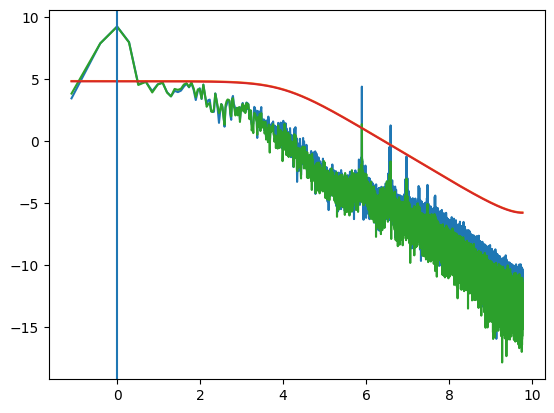

In [31]:
plt.plot(np.log(f_temp[:,2,0] * 365), np.log(psd_temp[:,2,0]))
plt.plot(np.log(f_temp[:,2,0] * 365), np.log(sig_temp[:,2,0]))
plt.plot(np.log(f_temp[:,2,1] * 365), np.log(psd_temp[:,2,1]))
plt.plot(np.log(f_temp[:,2,1] * 365), np.log(sig_temp[:,2,1]))
plt.axvline(np.log(1))
# plt.xlim(-5,1000)